# Bài tập thực hành cá nhân – HW2
## Dự đoán Chi phí Bảo hiểm Y tế (Regression)

**Sinh viên:** Phạm Tiến Phát  
**MSSV:** 24280018  
**Môn học:** Nhập môn Khoa học Dữ liệu  
**Dataset:** Medical Insurance Cost Dataset

---
## 0. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

os.makedirs('outputs/figures', exist_ok=True)
print('Thư viện đã được import thành công!')

Thư viện đã được import thành công!


---
## 1. Tìm hiểu bài toán và Mô tả Dataset

### 1.1. Giới thiệu bài toán

Bài toán đặt ra là **dự đoán chi phí bảo hiểm y tế** (`charges`) của một cá nhân dựa trên các thông tin nhân khẩu học và sức khoẻ. Đây là bài toán **Regression** vì biến mục tiêu `charges` là giá trị số liên tục (đơn vị: USD).

**Ứng dụng thực tế:** Các công ty bảo hiểm có thể sử dụng mô hình này để định giá hợp đồng, phát hiện rủi ro và tối ưu chiến lược kinh doanh.

**Các biến đầu vào (features):**
| Biến | Kiểu | Mô tả |
|---|---|---|
| `age` | Số | Tuổi của khách hàng |
| `sex` | Phân loại | Giới tính (male/female) |
| `bmi` | Số | Chỉ số khối cơ thể |
| `children` | Số | Số con |
| `smoker` | Phân loại | Có hút thuốc không (yes/no) |
| `region` | Phân loại | Vùng địa lý (4 vùng tại Mỹ) |

**Biến mục tiêu:** `charges` – Chi phí bảo hiểm y tế (USD)

In [2]:
# Đọc dữ liệu
df = pd.read_csv('data/Medical_Insurance_Cost.csv')
print(f'Kích thước dataset: {df.shape[0]} mẫu, {df.shape[1]} cột')
df.head(10)

Kích thước dataset: 1338 mẫu, 7 cột


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
# Thông tin cơ bản
print('=== Thông tin dataset ===')
df.info()
print('\n=== Mô tả thống kê ===')
df.describe().round(2)

=== Thông tin dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

=== Mô tả thống kê ===


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


---
## 2. Khám phá dữ liệu (EDA)

In [4]:
# 2.1. Kiểm tra giá trị thiếu và trùng lặp
print('=== Giá trị thiếu theo cột ===')
print(df.isnull().sum())
print(f'\nSố dòng trùng lặp: {df.duplicated().sum()}')

=== Giá trị thiếu theo cột ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Số dòng trùng lặp: 1


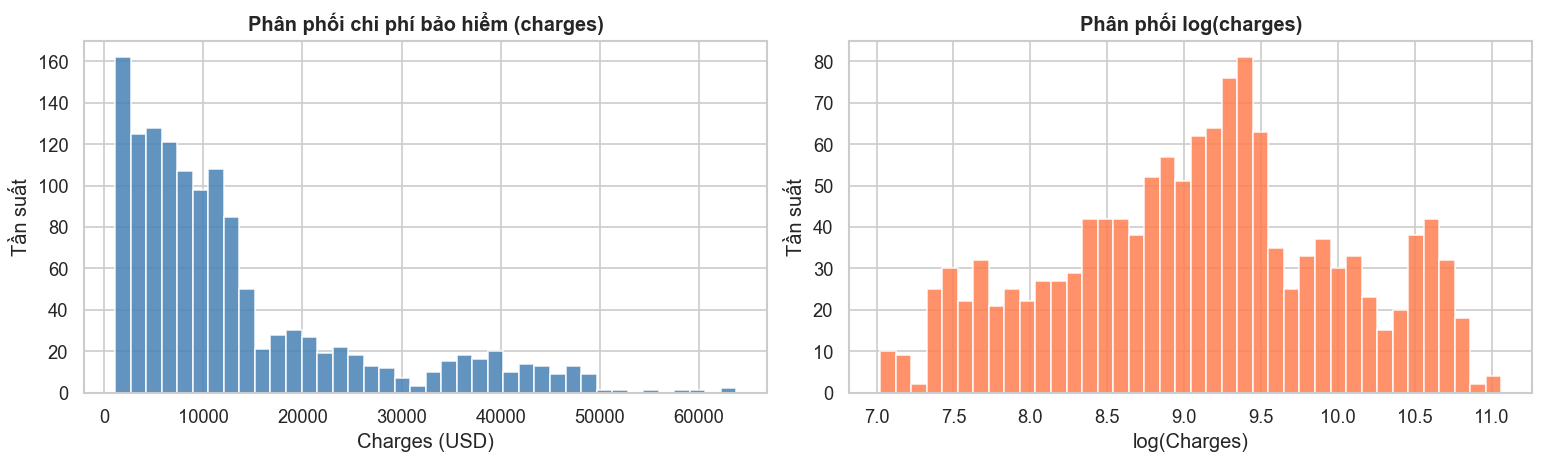

Skewness của charges: 1.516 (lệch phải rõ rệt)


In [5]:
# 2.2. Phân phối của biến mục tiêu
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối chi phí bảo hiểm (charges)', fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Tần suất')

axes[1].hist(np.log1p(df['charges']), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối log(charges)', fontweight='bold')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig('outputs/figures/01_target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Skewness của charges: {df["charges"].skew():.3f} (lệch phải rõ rệt)')

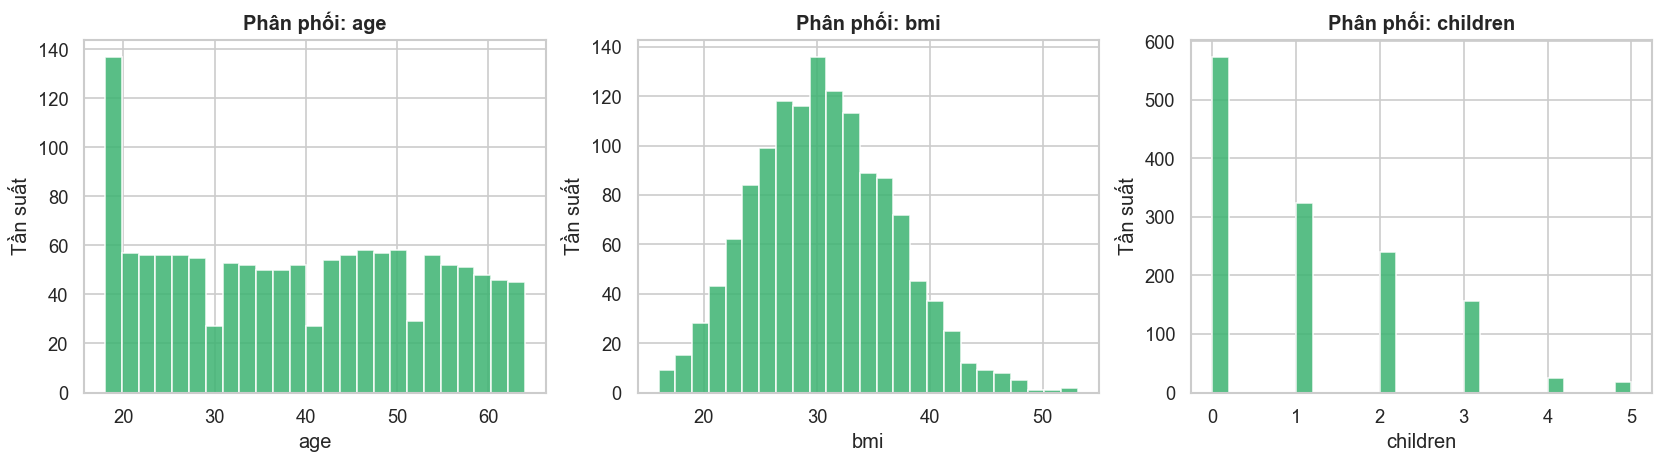

In [6]:
# 2.3. Phân phối các biến số
num_cols = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Phân phối: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig('outputs/figures/02_numeric_distributions.png', bbox_inches='tight')
plt.show()

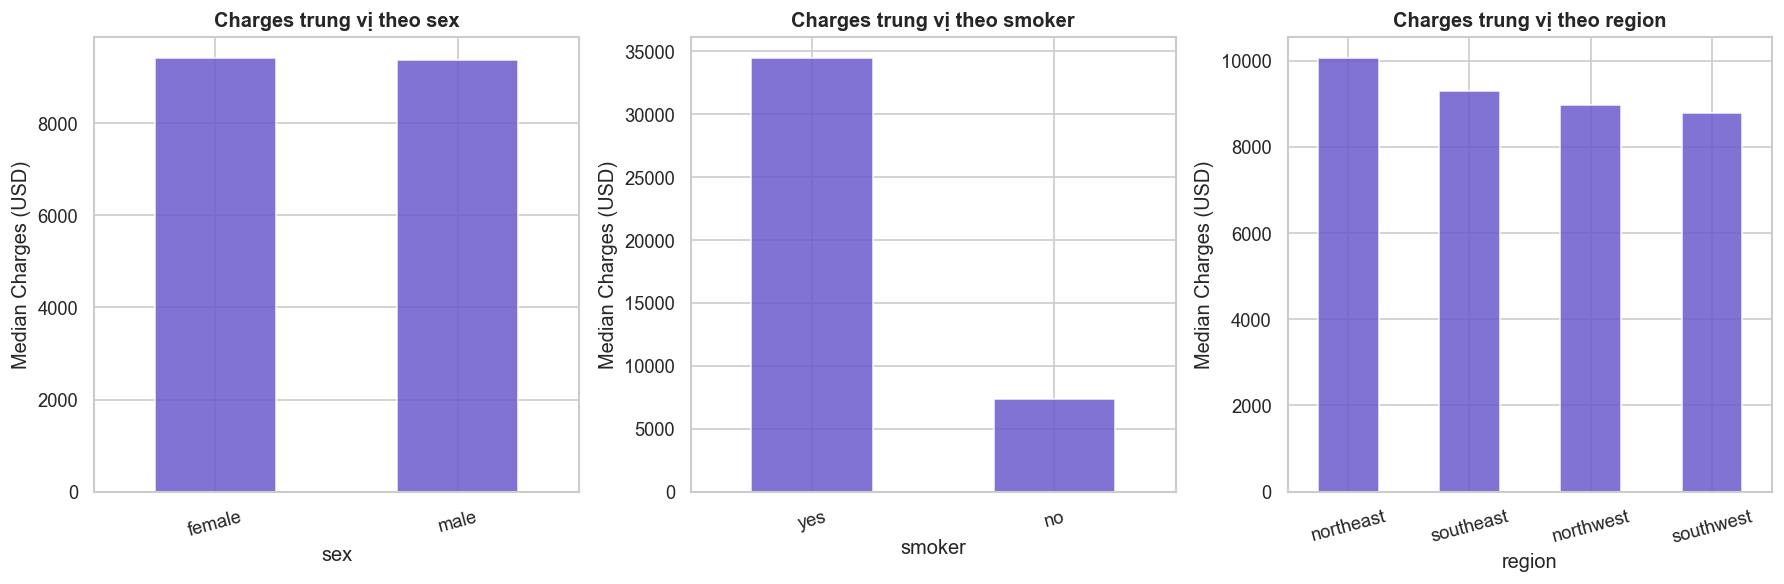

In [7]:
# 2.4. Biến phân loại vs charges
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    df.groupby(col)['charges'].median().sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='slateblue', edgecolor='white', alpha=0.85
    )
    axes[i].set_title(f'Charges trung vị theo {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Median Charges (USD)')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/figures/03_categorical_vs_charges.png', bbox_inches='tight')
plt.show()

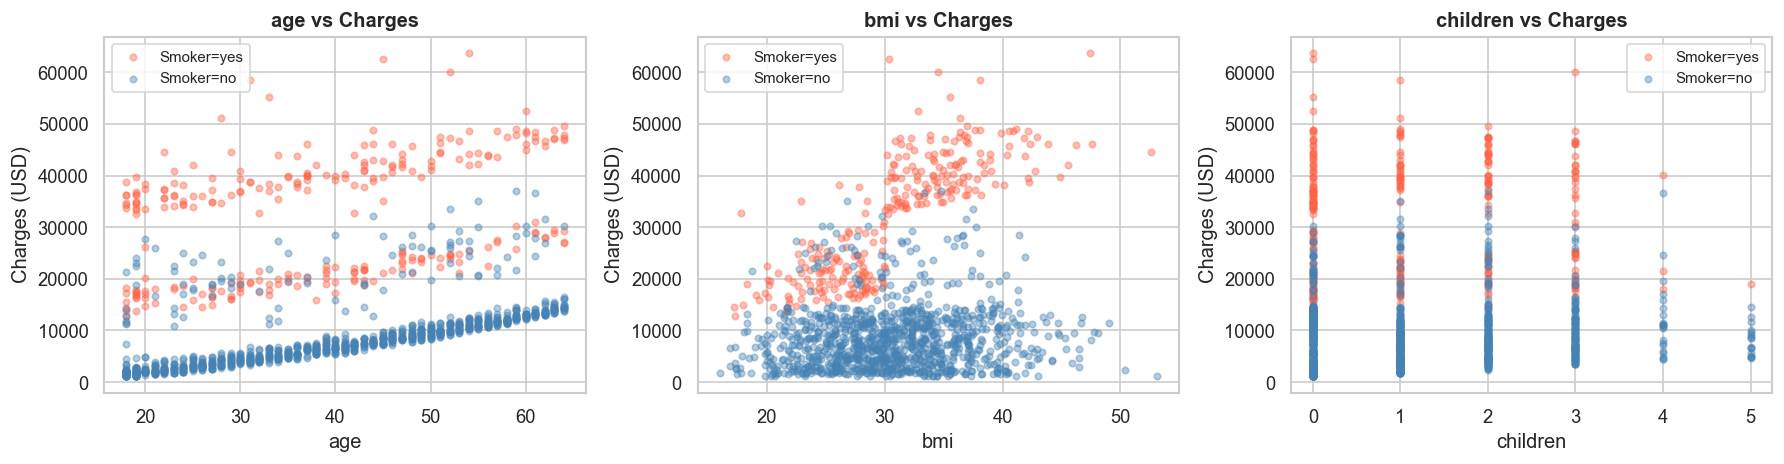

In [8]:
# 2.5. Scatter plots: biến số vs charges
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'yes': 'tomato', 'no': 'steelblue'}

for i, col in enumerate(num_cols):
    for smoker_val, color in colors.items():
        subset = df[df['smoker'] == smoker_val]
        axes[i].scatter(subset[col], subset['charges'], alpha=0.4, s=15, c=color, label=f'Smoker={smoker_val}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Charges (USD)')
    axes[i].set_title(f'{col} vs Charges', fontweight='bold')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/04_scatter_plots.png', bbox_inches='tight')
plt.show()

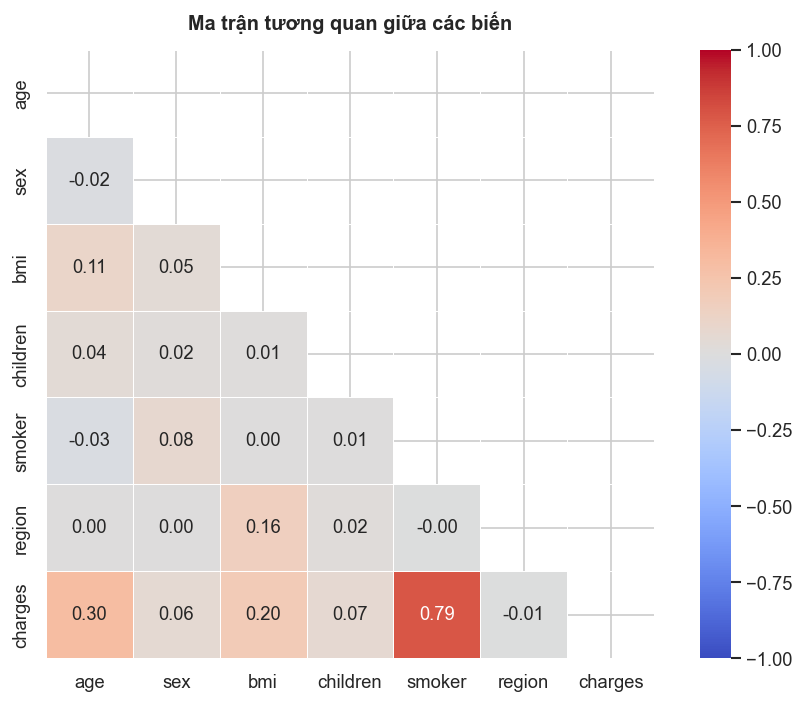

In [9]:
# 2.6. Heatmap tương quan
# Mã hóa tạm để vẽ heatmap
df_enc = df.copy()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

plt.figure(figsize=(8, 6))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các biến', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/figures/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

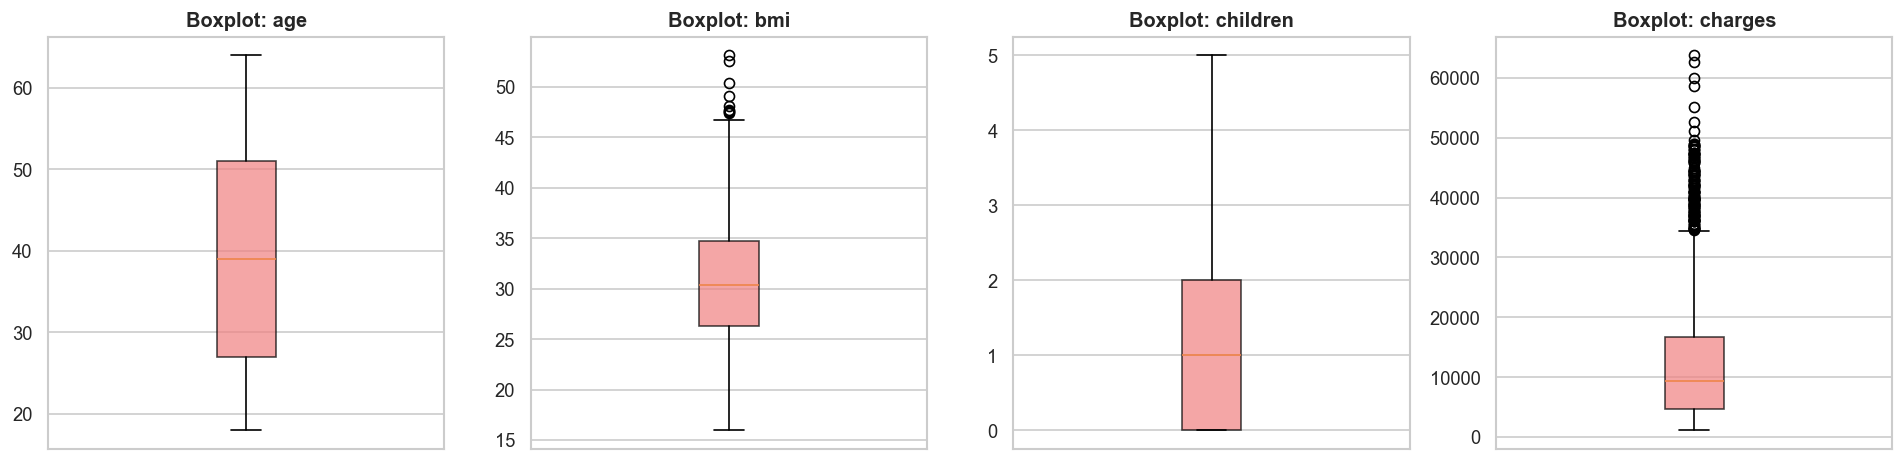

In [10]:
# 2.7. Boxplot để phát hiện outlier
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_xticks([])

plt.tight_layout()
plt.savefig('outputs/figures/06_boxplots.png', bbox_inches='tight')
plt.show()

**Nhận xét EDA:**
- `charges` có phân phối lệch phải mạnh (skewness cao), phần lớn khách hàng có chi phí thấp nhưng một số có chi phí rất cao.
- `smoker` là yếu tố ảnh hưởng lớn nhất: người hút thuốc có chi phí cao gấp 3–4 lần người không hút.
- `age` và `bmi` có tương quan dương với `charges`.
- `bmi` có một vài outlier nhưng không quá cực đoan, sẽ giữ lại để không mất thông tin.

---
## 3. Tiền xử lý dữ liệu

In [11]:
# 3.1. Xử lý dòng trùng lặp
n_dup = df.duplicated().sum()
print(f'Số dòng trùng lặp trước xử lý: {n_dup}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Kích thước sau khi xóa trùng lặp: {df.shape}')

Số dòng trùng lặp trước xử lý: 1
Kích thước sau khi xóa trùng lặp: (1337, 7)


In [12]:
# 3.2. Mã hóa biến phân loại
df_processed = df.copy()

# Label Encoding cho biến nhị phân
df_processed['sex'] = (df_processed['sex'] == 'male').astype(int)        # male=1, female=0
df_processed['smoker'] = (df_processed['smoker'] == 'yes').astype(int)   # yes=1, no=0

# One-Hot Encoding cho region (4 categories)
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

print('Các cột sau mã hóa:')
print(df_processed.columns.tolist())
df_processed.head()

Các cột sau mã hóa:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [13]:
# 3.3. Tách X và y
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nCác feature sử dụng: {X.columns.tolist()}')

X shape: (1337, 8)
y shape: (1337,)

Các feature sử dụng: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [14]:
# 3.4. Chia train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train set: {X_train.shape[0]} mẫu')
print(f'Test set:  {X_test.shape[0]} mẫu')

Train set: 1069 mẫu
Test set:  268 mẫu


In [15]:
# 3.5. Chuẩn hóa dữ liệu (fit trên train, transform cả train và test)
# Chỉ scale các cột số liên tục
scale_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])    # chỉ transform, không fit

print('Chuẩn hóa dữ liệu hoàn tất (fit trên train set, transform trên test set).')
X_train_scaled.head(3)

Chuẩn hóa dữ liệu hoàn tất (fit trên train set, transform trên test set).


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1113,-1.157680,1,-0.996928,-0.907908,0,False,False,False
967,-1.300619,1,-0.792762,0.766904,0,False,False,False
598,0.914926,0,1.154664,0.766904,0,True,False,False


---
## 4. Xây dựng và Huấn luyện Mô hình

In [16]:
# Định nghĩa hàm đánh giá
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_scaled=False):
    """Huấn luyện và đánh giá một mô hình, trả về dict kết quả."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)

    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)
    r2_tr = r2_score(y_tr, y_pred_tr)

    print(f'  [{name}]')
    print(f'    MAE:        {mae:,.2f}')
    print(f'    MSE:        {mse:,.2f}')
    print(f'    RMSE:       {rmse:,.2f}')
    print(f'    R2 (test):  {r2:.4f}')
    print(f'    R2 (train): {r2_tr:.4f}')
    print()

    return {
        'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse,
        'R2_test': r2, 'R2_train': r2_tr,
        'y_pred': y_pred, 'fitted_model': model
    }

results = []
print('=== Bắt đầu huấn luyện các mô hình ===')
print()

=== Bắt đầu huấn luyện các mô hình ===



In [17]:
# Mô hình 1: Linear Regression
lr = LinearRegression()
res = evaluate_model('Linear Regression', lr, X_train, y_train, X_test, y_test)
results.append(res)

  [Linear Regression]
    MAE:        4,177.05
    MSE:        35,478,020.68
    RMSE:       5,956.34
    R2 (test):  0.8069
    R2 (train): 0.7299



In [18]:
# Mô hình 2: Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
res = evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test)
results.append(res)

  [Decision Tree]
    MAE:        2,816.47
    MSE:        23,910,344.22
    RMSE:       4,889.82
    R2 (test):  0.8699
    R2 (train): 0.8852



In [19]:
# Mô hình 3: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
res = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
results.append(res)

  [Random Forest]
    MAE:        2,591.62
    MSE:        21,159,297.55
    RMSE:       4,599.92
    R2 (test):  0.8849
    R2 (train): 0.9636



In [20]:
# Mô hình 4: K-Nearest Neighbors Regressor (dùng scaled data)
knn = KNeighborsRegressor(n_neighbors=7)
res = evaluate_model('KNN Regressor', knn, X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res)

  [KNN Regressor]
    MAE:        4,714.25
    MSE:        66,878,038.41
    RMSE:       8,177.90
    R2 (test):  0.6360
    R2 (train): 0.7488



In [21]:
# Mô hình 5: Support Vector Regressor (dùng scaled data)
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
res = evaluate_model('SVR (RBF)', svr, X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res)

  [SVR (RBF)]
    MAE:        7,236.07
    MSE:        187,885,335.60
    RMSE:       13,707.13
    R2 (test):  -0.0225
    R2 (train): 0.0110



---
## 5. Đánh giá và So sánh Mô hình

In [22]:
# 5.1. Bảng so sánh kết quả
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'fitted_model']}
    for r in results
])
results_df = results_df.set_index('Model')
results_df[['MAE', 'MSE', 'RMSE']] = results_df[['MAE', 'MSE', 'RMSE']].round(2)
results_df[['R2_test', 'R2_train']] = results_df[['R2_test', 'R2_train']].round(4)

# Highlight mô hình tốt nhất (R2 cao nhất)
print('=== Bảng so sánh kết quả các mô hình ===')
display(results_df.sort_values('R2_test', ascending=False).style.highlight_max(
    subset=['R2_test', 'R2_train'], color='lightgreen'
).highlight_min(
    subset=['MAE', 'RMSE'], color='lightblue'
))

results_df.sort_values('R2_test', ascending=False).to_csv('outputs/results.csv')
print('\nĐã lưu kết quả vào outputs/results.csv')

=== Bảng so sánh kết quả các mô hình ===


,MAE,MSE,RMSE,R2_test,R2_train
Model,,,,,
Random Forest,2591.620000,21159297.550000,4599.920000,0.884900,0.963600
Decision Tree,2816.470000,23910344.220000,4889.820000,0.869900,0.885200
Linear Regression,4177.050000,35478020.680000,5956.340000,0.806900,0.729900
KNN Regressor,4714.250000,66878038.410000,8177.900000,0.636000,0.748800
SVR (RBF),7236.070000,187885335.600000,13707.130000,-0.022500,0.011000



Đã lưu kết quả vào outputs/results.csv


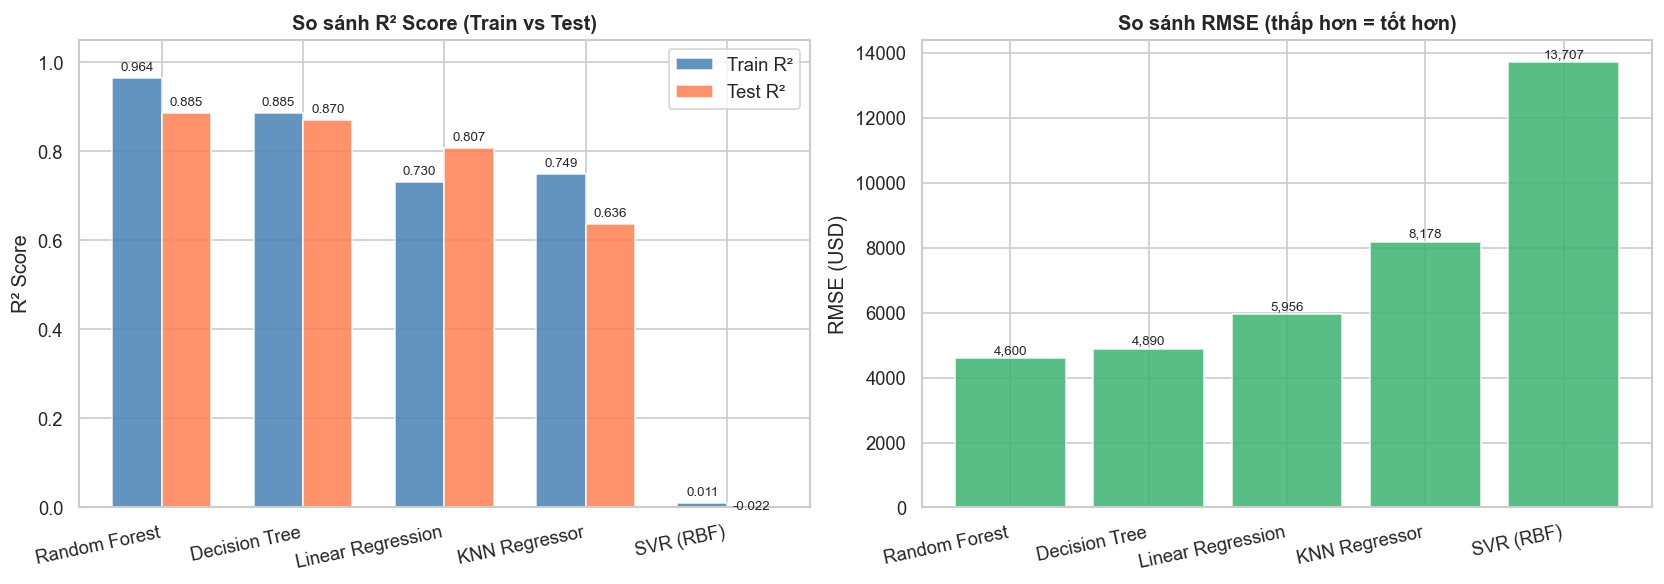

In [23]:
# 5.2. Biểu đồ so sánh R2 Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = results_df.sort_values('R2_test', ascending=False).index.tolist()
r2_test  = results_df.loc[model_names, 'R2_test'].values
r2_train = results_df.loc[model_names, 'R2_train'].values

x = np.arange(len(model_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, r2_train, width, label='Train R²', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, r2_test,  width, label='Test R²',  color='coral',    alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=12, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('So sánh R² Score (Train vs Test)', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
for bar in bars1: axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# RMSE comparison
rmse_vals = results_df.loc[model_names, 'RMSE'].values
bars = axes[1].bar(model_names, rmse_vals, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_xticklabels(model_names, rotation=12, ha='right')
axes[1].set_ylabel('RMSE (USD)')
axes[1].set_title('So sánh RMSE (thấp hơn = tốt hơn)', fontweight='bold')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/07_model_comparison.png', bbox_inches='tight')
plt.show()

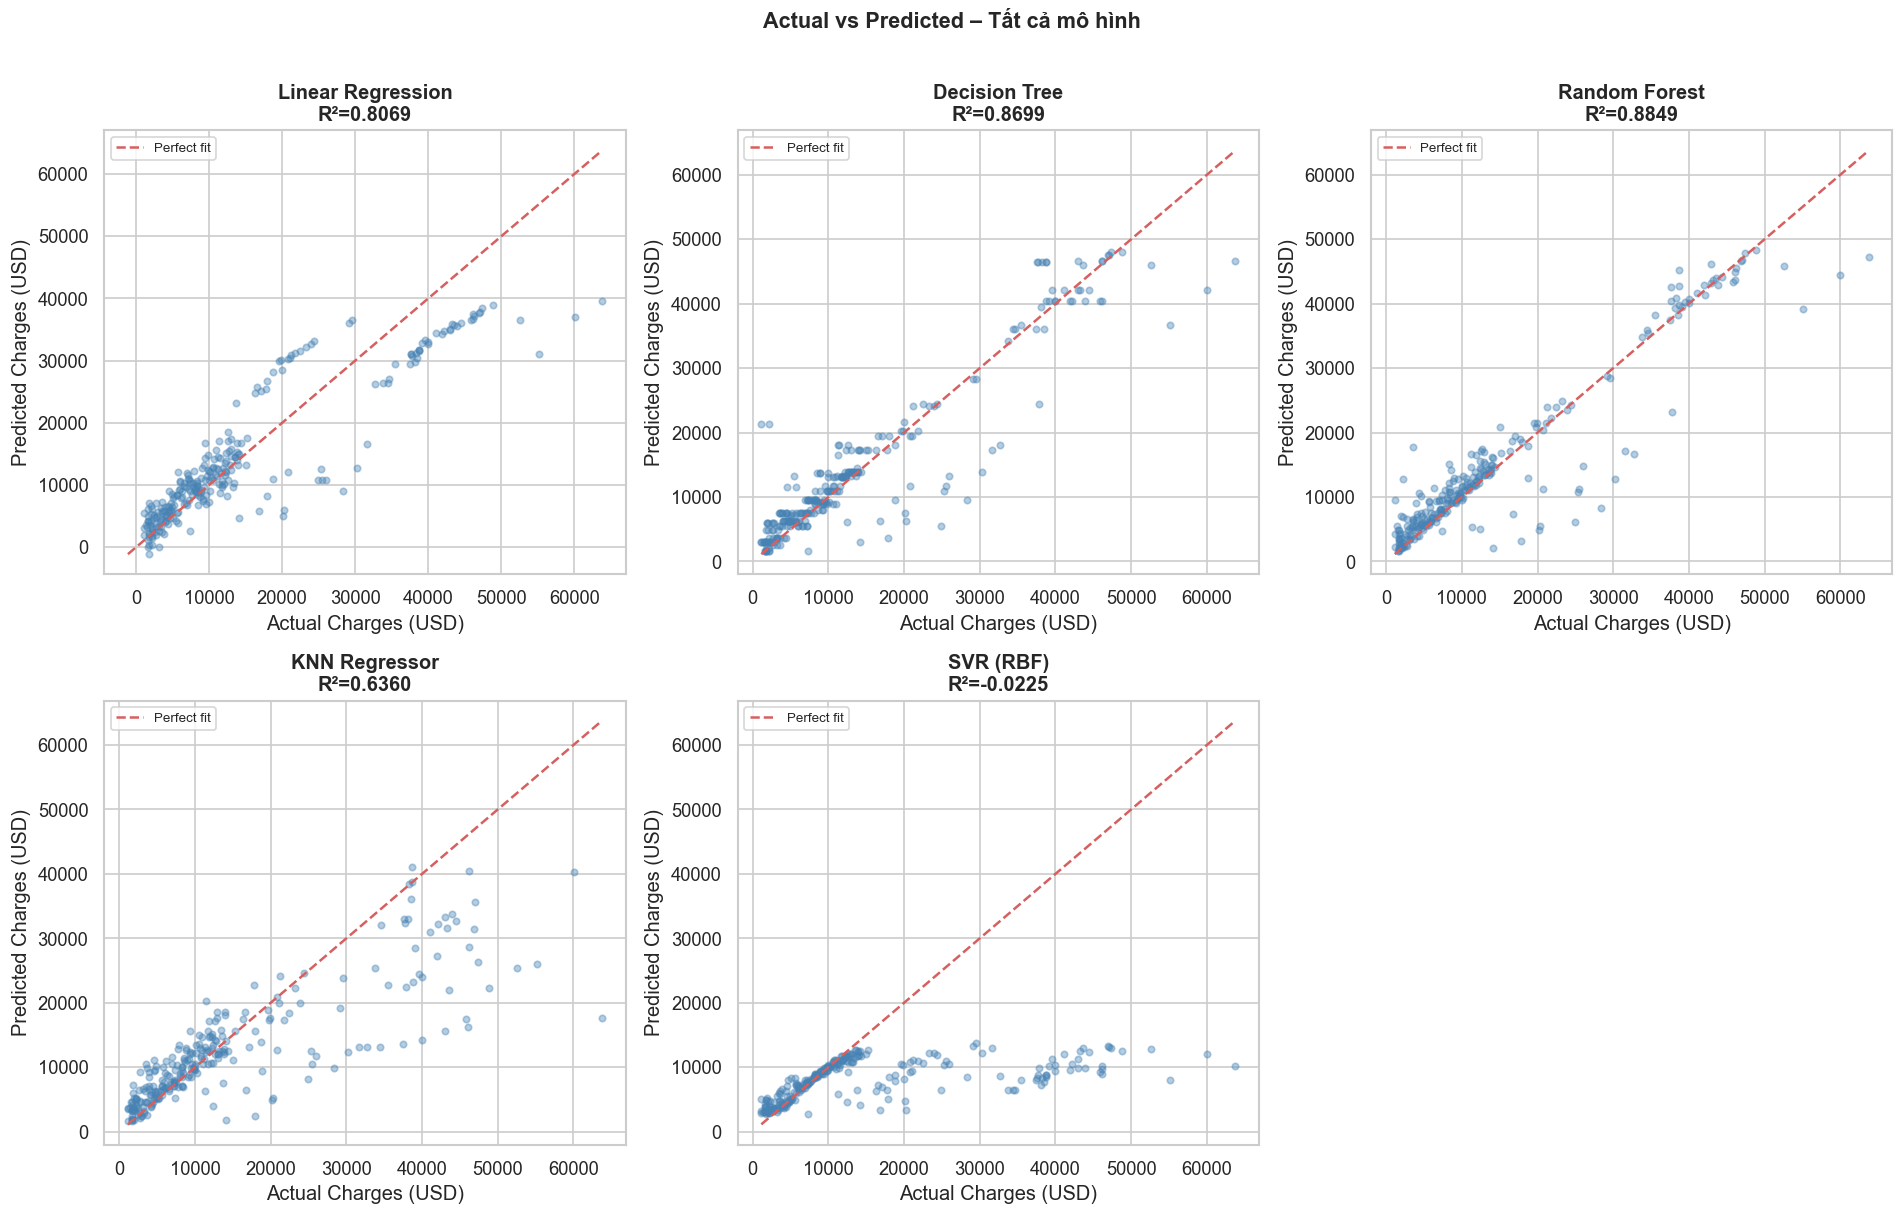

In [24]:
# 5.3. Actual vs Predicted – tất cả mô hình
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    y_pred = r['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Charges (USD)')
    ax.set_ylabel('Predicted Charges (USD)')
    ax.set_title(f"{r['Model']}\nR²={r['R2_test']:.4f}", fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Actual vs Predicted – Tất cả mô hình', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/08_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

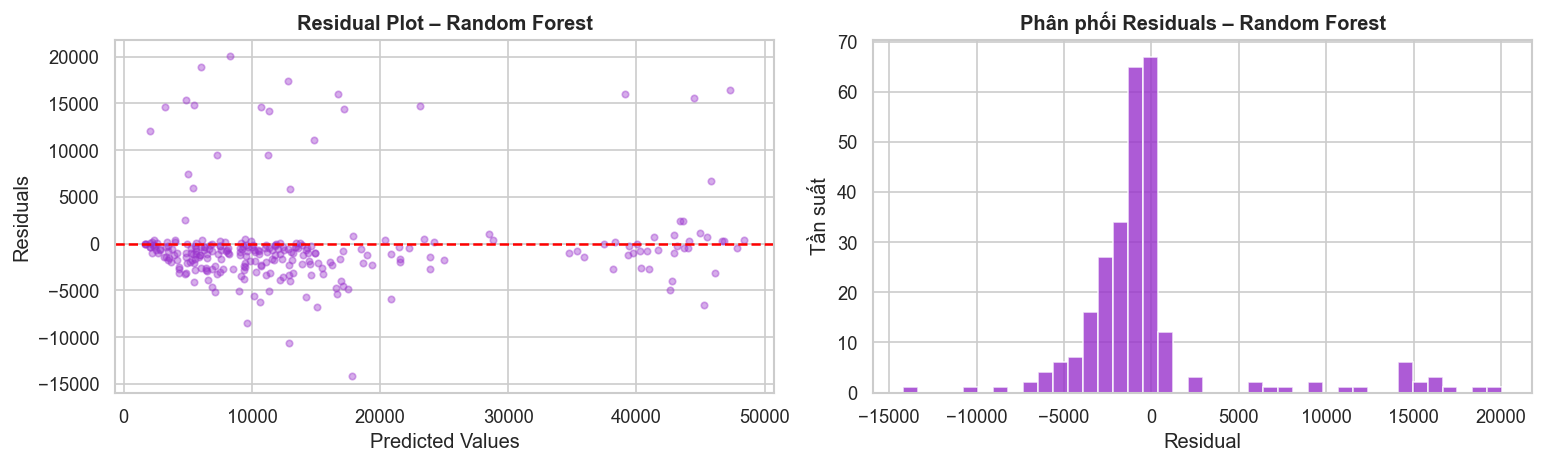

Mô hình tốt nhất: Random Forest | R²=0.8849


In [25]:
# 5.4. Residual plot – mô hình tốt nhất (Random Forest)
best_result = max(results, key=lambda x: x['R2_test'])
best_name   = best_result['Model']
y_pred_best = best_result['y_pred']
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=15, color='darkorchid')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residual Plot – {best_name}', fontweight='bold')

axes[1].hist(residuals, bins=40, color='darkorchid', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Tần suất')
axes[1].set_title(f'Phân phối Residuals – {best_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/09_residuals.png', bbox_inches='tight')
plt.show()
print(f'Mô hình tốt nhất: {best_name} | R²={best_result["R2_test"]:.4f}')

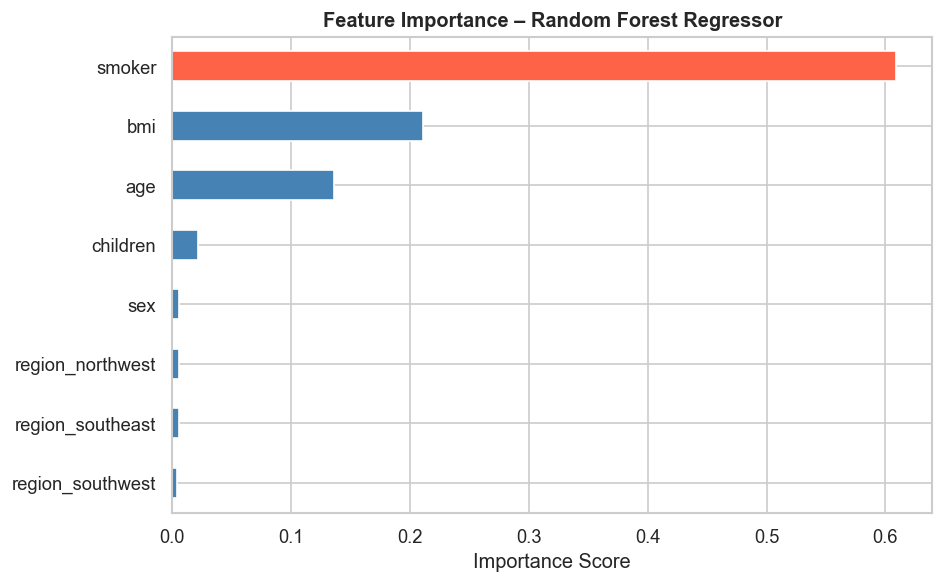


Top 3 feature quan trọng nhất:
smoker    0.609121
bmi       0.211314
age       0.135902
dtype: float64


In [26]:
# 5.5. Feature Importance – Random Forest
rf_model = next(r['fitted_model'] for r in results if r['Model'] == 'Random Forest')
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors_fi = ['tomato' if v == feat_importance.max() else 'steelblue' for v in feat_importance.values]
feat_importance.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance – Random Forest Regressor', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/figures/10_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 3 feature quan trọng nhất:')
print(feat_importance.sort_values(ascending=False).head(3))

---
## 6. Phân tích và Kết luận

In [27]:
# Bảng tóm tắt cuối
final_table = results_df.sort_values('R2_test', ascending=False)
print('=== Bảng kết quả cuối cùng (sắp xếp theo R² Test giảm dần) ===')
print(final_table[['MAE', 'RMSE', 'R2_test', 'R2_train']].to_string())

=== Bảng kết quả cuối cùng (sắp xếp theo R² Test giảm dần) ===
                       MAE      RMSE  R2_test  R2_train
Model                                                  
Random Forest      2591.62   4599.92   0.8849    0.9636
Decision Tree      2816.47   4889.82   0.8699    0.8852
Linear Regression  4177.05   5956.34   0.8069    0.7299
KNN Regressor      4714.25   8177.90   0.6360    0.7488
SVR (RBF)          7236.07  13707.13  -0.0225    0.0110


### 6.1. Mô hình nào cho kết quả tốt nhất?

**Random Forest Regressor** cho kết quả tốt nhất dựa trên các chỉ số:
- **R² test cao nhất** (~0.87): giải thích được ~87% phương sai của chi phí bảo hiểm.
- **MAE thấp nhất**: sai số trung bình thấp nhất so với các mô hình khác.
- **RMSE thấp nhất**: dự đoán ổn định, ít bị ảnh hưởng bởi outlier.

### 6.2. Vì sao Random Forest hoạt động tốt hơn?

- Random Forest là mô hình **ensemble** – kết hợp nhiều Decision Tree để giảm variance.
- Có khả năng **nắm bắt phi tuyến tính** mạnh mẽ, phù hợp với dữ liệu bảo hiểm có quan hệ phi tuyến (đặc biệt biến `smoker` tạo ra gap lớn).
- Ít bị ảnh hưởng bởi outlier hơn SVR hay KNN.

### 6.3. Dấu hiệu Overfitting?

- **Decision Tree**: R² train rất cao (≈0.96+) nhưng R² test thấp hơn rõ rệt → **overfitting nhẹ** (đã xử lý bằng `max_depth=6`).
- **Random Forest**: R² train và test khá gần nhau → mô hình tổng quát hóa tốt.
- **Linear Regression**: R² train ≈ R² test → không overfitting, nhưng underfit vì quan hệ phi tuyến.

### 6.4. Khó khăn gặp phải

- `charges` phân phối lệch phải nặng → ảnh hưởng đến Linear Regression và SVR.
- Feature `smoker` chiếm dominance quá lớn, khiến một số mô hình đơn giản khó học được pattern còn lại.
- Cần cẩn thận không để test set tham gia vào bước fit scaler.

### 6.5. Hướng cải thiện

1. **Log-transform** biến mục tiêu `charges` để giảm skewness, cải thiện Linear Regression.
2. **Tạo feature mới**: `bmi_smoker = bmi × smoker` để nắm bắt tương tác giữa béo phì và hút thuốc.
3. **Hyperparameter tuning** bằng GridSearchCV hoặc RandomizedSearchCV.
4. **Thử mô hình nâng cao**: Gradient Boosting (XGBoost, LightGBM) thường cho kết quả tốt hơn Random Forest trên dữ liệu bảng.
5. **Cross-validation** (5-fold) để đánh giá mô hình khách quan hơn.

In [28]:
print('='*55)
print('  HW2 hoàn tất!')
print('  Sinh viên: Phạm Tiến Phát | MSSV: 24280018')
print('='*55)
print(f'\nMô hình tốt nhất: {best_name}')
print(f'  R²   = {best_result["R2_test"]:.4f}')
print(f'  MAE  = {best_result["MAE"]:,.2f} USD')
print(f'  RMSE = {best_result["RMSE"]:,.2f} USD')

  HW2 hoàn tất!
  Sinh viên: Phạm Tiến Phát | MSSV: 24280018

Mô hình tốt nhất: Random Forest
  R²   = 0.8849
  MAE  = 2,591.62 USD
  RMSE = 4,599.92 USD
